Praktikum Certan Week 03 Sesi 03

Topik	Polynomial Regression

Bagian A: Polynomial Regression (1 Predictor - Data Ice Cream)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

path = "Ice_cream_selling_data.csv"
df = pd.read_csv(path)
print(df.head())

   Temperature (°C)  Ice Cream Sales (units)
0         -4.662263                41.842986
1         -4.316559                34.661120
2         -4.213985                39.383001
3         -3.949661                37.539845
4         -3.578554                32.284531


In [3]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

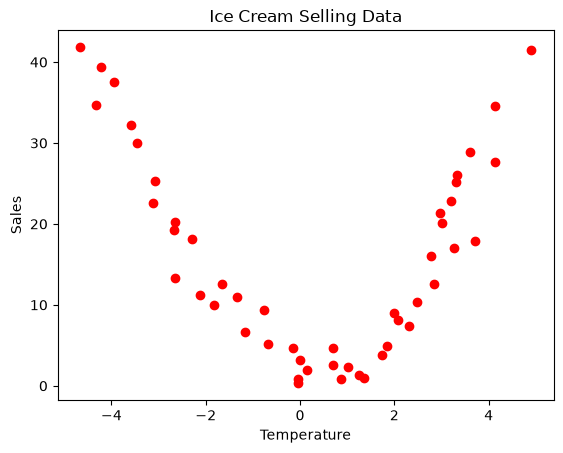

In [4]:
plt.scatter(X, y, color='red')
plt.title('Ice Cream Selling Data')
plt.xlabel('Temperature')
plt.ylabel('Sales')
plt.show()

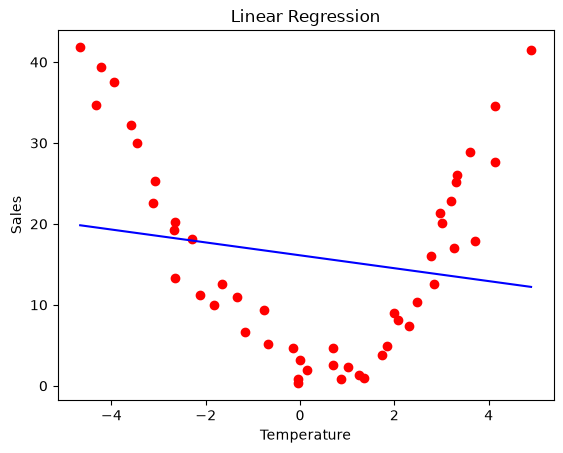

In [5]:
linear_model = LinearRegression()
linear_model.fit(X, y)
plt.scatter(X, y, color='red')
plt.plot(X, linear_model.predict(X), color='blue')
plt.title('Linear Regression')
plt.xlabel('Temperature')
plt.ylabel('Sales')
plt.show()

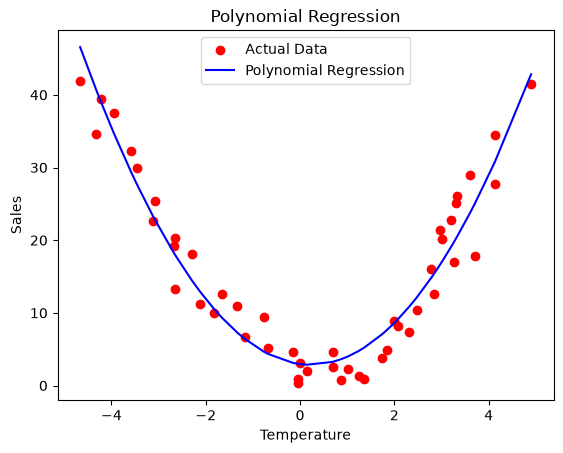

In [6]:
poly_reg = PolynomialFeatures(degree=2)
X_poly = poly_reg.fit_transform(X)

linear_model2 = LinearRegression()
linear_model2.fit(X_poly, y)
y_pred_poly = linear_model2.predict(X_poly)

plt.scatter(X, y, color='red', label="Actual Data")
plt.plot(X, y_pred_poly, color='blue', label="Polynomial Regression")
plt.title('Polynomial Regression')
plt.xlabel('Temperature')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [7]:
print('Intercept: ', linear_model2.intercept_)
print('Coefficient:', linear_model2.coef_)
print('Equation: y =', linear_model2.intercept_, '+', linear_model2.coef_[1], 'x +', linear_model2.coef_[2], 'x^2')

Intercept:  2.951774157993448
Coefficient: [ 0.         -0.82468167  1.82952623]
Equation: y = 2.951774157993448 + -0.8246816702106476 x + 1.8295262296702082 x^2


Bagian B: Polynomial Regression Multiple Predictors (Data Manufacturing)

In [8]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

dataset = pd.read_csv('manufacturing.csv')
print(dataset.head())

   Temperature (°C)  Pressure (kPa)  Temperature x Pressure  \
0        209.762701        8.050855             1688.769167   
1        243.037873       15.812068             3842.931469   
2        220.552675        7.843130             1729.823314   
3        208.976637       23.786089             4970.736918   
4        184.730960       15.797812             2918.345014   

   Material Fusion Metric  Material Transformation Metric  Quality Rating  
0            44522.217074                    9.229576e+06       99.999971  
1            63020.764997                    1.435537e+07       99.985703  
2            49125.950249                    1.072839e+07       99.999758  
3            57128.881547                    9.125702e+06       99.999975  
4            38068.201283                    6.303792e+06      100.000000  


In [9]:
X = dataset.iloc[:, 2:5].values
y = dataset.iloc[:, 5].values

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [11]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

poly_reg = PolynomialFeatures(degree=2)
X_train_poly = poly_reg.fit_transform(X_train)
X_test_poly = poly_reg.transform(X_test)

linear_model2 = LinearRegression()
linear_model2.fit(X_train_poly, y_train)
y_pred = linear_model2.predict(X_test_poly)

In [12]:
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
score

0.7103025312554145

Tugas Analisis perbedaan R-square score polynomial derajat 1, 3, 5, untuk Polynomial Regression dengan lebih dari satu predictor

In [22]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

dataset = pd.read_csv('manufacturing.csv')

X = dataset.iloc[:, 2:5].values
y = dataset.iloc[:, 5].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

degrees = [1, 3, 5]

for deg in degrees:
    poly_reg = PolynomialFeatures(degree=deg)
    X_train_poly = poly_reg.fit_transform(X_train)
    X_test_poly = poly_reg.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    y_pred = model.predict(X_test_poly)
    
    score = r2_score(y_test, y_pred)
    print(f"R2 Score untuk Derajat {deg}: {score}")

R2 Score untuk Derajat 1: 0.46902642617650725
R2 Score untuk Derajat 3: 0.8246285387828609
R2 Score untuk Derajat 5: 0.9207811071581241
